# Загрузка библиотек

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import warnings

from grokking_model import GrokkingTransformer
from grokking_utils import get_s5_composition_data, get_weight_norm, plot_grokking_replication

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float64)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

Using cuda:0


# Генерация и предобработка данных

In [20]:
FRACTION = 0.5

X_train, Y_train, X_test, Y_test, num_total, num_elements = get_s5_composition_data(
    fraction=FRACTION, seed=42, device=device
)

BATCH_SIZE = 256
VAL_BATCH_SIZE = 512

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

fixed_val_x = X_test[:VAL_BATCH_SIZE]
fixed_val_y = Y_test[:VAL_BATCH_SIZE]

print(f"S_5 Elements: {num_elements} | Total combinations: {num_total}")
print(f"Train size: {len(X_train)} | Fixed Val size: {len(fixed_val_x)}")

S_5 Elements: 120 | Total combinations: 14400
Train size: 7200 | Fixed Val size: 512


# Архитектура модели

In [21]:
VOCAB_SIZE = num_elements + 1

model = GrokkingTransformer(d_vocab=VOCAB_SIZE).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=2e-1, betas=(0.9, 0.98))
criterion = nn.CrossEntropyLoss()

MAX_STEPS = 15000
LOG_FREQ = 5

logs = {
    'step': [], 'train_loss': [], 'val_loss':[], 'train_acc': [], 'val_acc': [],
    'weight_norm': [], 'grad_norm':[], 'embed_grad_norm': [], 'grad_cosine':[]
}

# Обучение

In [22]:
print("\nStarting Mini-Batch Grokking Training...")
global_step = 0
loop = tqdm(total=MAX_STEPS)

prev_grad_vector = None

current_grad_norm = 0.0
current_embed_grad_norm = 0.0
current_grad_cosine = 0.0

while global_step < MAX_STEPS:
    for batch_x, batch_y in train_loader:
        if global_step >= MAX_STEPS:
            break

        model.train()
        optimizer.zero_grad()

        logits_train = model(batch_x)
        train_loss = criterion(logits_train, batch_y)
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            current_grad_norm = torch.sqrt(sum(p.grad.pow(2).sum() for p in model.parameters() if p.grad is not None)).item()

            if model.embed.W_E.grad is not None:
                current_embed_grad_norm = model.embed.W_E.grad.norm(2).item()
            else:
                current_embed_grad_norm = 0.0

            curr_grad_vector = torch.cat([p.grad.view(-1) for p in model.parameters() if p.grad is not None])

            if prev_grad_vector is not None:
                current_grad_cosine = F.cosine_similarity(curr_grad_vector.unsqueeze(0), prev_grad_vector.unsqueeze(0)).item()
            else:
                current_grad_cosine = 0.0

            prev_grad_vector = curr_grad_vector.clone().detach()

        optimizer.step()

        if global_step % LOG_FREQ == 0:
            with torch.no_grad():
                model.eval()
                acc_train = (logits_train.argmax(dim=1) == batch_y).float().mean().item()

                logits_val = model(fixed_val_x)
                val_loss = criterion(logits_val, fixed_val_y)
                acc_val = (logits_val.argmax(dim=1) == fixed_val_y).float().mean().item()

                w_norm = get_weight_norm(model)

                logs['step'].append(global_step)
                logs['train_loss'].append(train_loss.item())
                logs['val_loss'].append(val_loss.item())
                logs['train_acc'].append(acc_train)
                logs['val_acc'].append(acc_val)
                logs['weight_norm'].append(w_norm)
                logs['grad_norm'].append(current_grad_norm)
                logs['embed_grad_norm'].append(current_embed_grad_norm)
                logs['grad_cosine'].append(current_grad_cosine)

                if global_step % 100 == 0:
                    loop.set_postfix(
                        t_L=f"{train_loss.item():.2f}",
                        v_acc=f"{acc_val:.2f}",
                        g_cos=f"{current_grad_cosine:.2f}"
                    )

        global_step += 1
        loop.update(1)

loop.close()


Starting Mini-Batch Grokking Training...


  0%|          | 0/15000 [00:00<?, ?it/s]

# Итоговые графики

Logs saved to 'grokking_s5_high_variance_logs.csv'


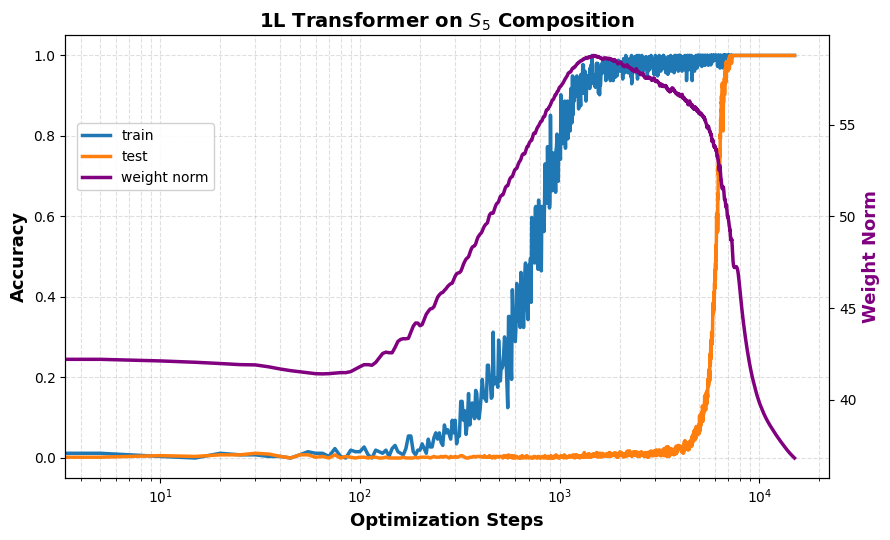

In [23]:
df_logs = pd.DataFrame(logs)
csv_name = 'grokking_s5_high_variance_logs.csv'
df_logs.to_csv(csv_name, index=False)
print(f"Logs saved to '{csv_name}'")

df_logs_for_plot = df_logs.rename(columns={'val_acc': 'test_acc'})
plot_grokking_replication(df_logs_for_plot, title="1L Transformer on $S_5$ Composition", save_path='omnigrok_s5_replication.pdf')